In [2]:
# ── Short-Term Memory via Message Deletion ─────────────────
# Goal  : control context window size using a *different* STM strategy —
#         removing old messages from state entirely rather than just slicing
#         the input to trim_messages().
# Contrast with notebook 10 (trim_messages):
#   Notebook 10  – trims the *input list* sent to the LLM; full history
#                  remains in state and the checkpoint.
#   Notebook 11  – permanently removes messages from state, reducing the
#                  checkpoint size and preventing unbounded DB growth.
# Concepts reinforced: HITL (interrupt / Command), ToolNode, SqliteSaver,
#                       RAG tool, token-budget management.
# ─────────────────────────────────────────────────────────────────────────

!uv pip install langgraph langchain langchain-core langchain-community chromadb pypdf langchain-google-genai ddgs langchain-mistralai dotenv langgraph-checkpoint-sqlite reportlab --quiet

In [21]:
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage, AIMessage, ToolMessage
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma

from langgraph.types import interrupt, Command

from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langchain_core.messages import RemoveMessage


import requests
import os

In [4]:
load_dotenv()

True

In [5]:
# ── LLM + Token Budget ───────────────────────────────────────────────────
# MAX_TOKEN caps how many tokens worth of history the LLM receives.
# In this notebook the budget is enforced by deleting messages from state.

llm = ChatMistralAI()
MAX_TOKEN = 150

In [6]:
loader = PyPDFLoader("./../data/yolo_melanoma_final.pdf")
docs = loader.load()

In [7]:
len(docs)

4

In [8]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [9]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001",)
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="data/chroma_database",
)

In [10]:
vector_store

In [11]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [12]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [13]:
# tools
search_tool = DuckDuckGoSearchRun(region="us-en")

In [14]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [15]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [16]:

from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from datetime import datetime

@tool
def generate_day_plan(tasks: list[str], start_hour: int = 7) -> dict:
    """
    Generate a structured day plan from a list of tasks.
    Each task is assigned a 1-hour block sequentially.
    """
    schedule = []
    current_hour = start_hour

    for task in tasks:
        start_time = f"{current_hour:02d}:00"
        end_time = f"{current_hour + 1:02d}:00"
        schedule.append({
            "start": start_time,
            "end": end_time,
            "task": task
        })
        current_hour += 1

    return {
        "date": datetime.now().strftime("%Y-%m-%d"),
        "schedule": schedule
    }


@tool
def generate_schedule_pdf(plan: dict, filename: str = "daily_plan.pdf") -> dict:
    """
    Generate a PDF for a structured day plan.
    Input must include:
    {
        "date": "...",
        "schedule": [{"start": "...", "end": "...", "task": "..."}]
    }
    """
    pdf = SimpleDocTemplate(filename, pagesize=A4)
    styles = getSampleStyleSheet()
    elements = []

    elements.append(Paragraph("DAILY PRODUCTIVITY PLAN", styles["Title"]))
    elements.append(Spacer(1, 12))
    elements.append(Paragraph(f"Date: {plan.get('date')}", styles["Normal"]))
    elements.append(Spacer(1, 12))

    table_data = [["Start", "End", "Task"]]

    for item in plan.get("schedule", []):
        table_data.append([item["start"], item["end"], item["task"]])

    table = Table(table_data, colWidths=[100, 100, 250])
    table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.grey),
        ("TEXTCOLOR", (0,0), (-1,0), colors.whitesmoke),
        ("GRID", (0,0), (-1,-1), 1, colors.black),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("PADDING", (0,0), (-1,0), 8),
    ]))

    elements.append(table)
    elements.append(Spacer(1, 20))
    elements.append(Paragraph("Notes:", styles["Heading3"]))
    elements.append(Paragraph("- Focus on execution", styles["Normal"]))

    pdf.build(elements)

    return {
        "status": "success",
        "file_path": filename
    }


In [17]:
# ── Tool List ────────────────────────────────────────────────────────────
# Expanded tools: stock price, web search (HITL-gated), calculator, RAG, scheduler, PDF export.

# Make tool list
tools = [get_stock_price, search_tool, calculator, rag_tool, generate_day_plan, generate_schedule_pdf]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [18]:
# ── Graph State ──────────────────────────────────────────────────────────
# Same ChatState as previous notebooks. Message deletion is handled inside
# chat_node before the LLM call, keeping the state schema unchanged.

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [19]:
# ── Chat Node with STM Trimming ──────────────────────────────────────────
# trim_messages() is still used to compute the input slice, but messages
# could also be removed from state via RemoveMessage to shrink the checkpoint.
# strategy='last' keeps the most recent messages within MAX_TOKEN.

def chat_node(state: ChatState):

    messages = trim_messages(
        state['messages'],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKEN
    )

    print("Current token count -> ", count_tokens_approximately(messages=messages))

    for message in messages:
        print("Message Content -> ", message.content)

    """LLM node that decides to answer directly or call a tool."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}
    

tool_node = ToolNode(tools)  # Executes tool calls

In [ ]:
def delete_old_messages(state: ChatState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [23]:
# --- HITL routing logic ---

def route_tools(state: ChatState):
    """
    Called after chat_node to decide where to go next:
      - No tool call        → END  (LLM answered directly)
      - duckduckgo_search   → human_approval  (needs human sign-off)
      - Any other tool      → tools  (execute immediately)
    """
    last_message = state["messages"][-1]
    if not getattr(last_message, "tool_calls", None):
        return END
    tool_name = last_message.tool_calls[0]["name"]
    if tool_name == "duckduckgo_search":
        return "human_approval"
    return "tools"

In [24]:
def human_approval_node(state: ChatState):
    """
    Pauses the graph and asks a human to approve or reject the
    pending web-search call.
      - Approved  → Command(goto='tools')  — proceeds to execute the search
      - Rejected  → Command(goto=END)      — returns a rejection message
    """
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    decision = interrupt({
        "type": "approval",
        "tool_name": tool_call["name"],
        "query": tool_call["args"].get("query", str(tool_call["args"])),
        "instruction": "Web search requires human approval. Approve? (yes/no)"
    })

    if decision.get("approved") == "no":
        # Mistral requires a ToolMessage for every tool_call in the history.
        # Without it, the next turn sends an unmatched tool_call → 400 error.
        # We insert a cancellation ToolMessage to satisfy that constraint.
        return Command(
            goto=END,
            update={"messages": [
                ToolMessage(
                    content="Cancelled: rejected by human reviewer.",
                    tool_call_id=tool_call["id"]
                ),
                AIMessage(content="❌ Web search was rejected by the human reviewer.")
            ]}
        )

    # Approved → proceed to tool execution
    return Command(goto="tools")

In [25]:
conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
# checkpointer
checkpointer = SqliteSaver(conn=conn)

In [34]:
# ── Graph Construction (same as notebook 9/10) ───────────────────────────
# Three nodes: chat_node, tools, human_approval (HITL gate for web search).

# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_node("human_approval", human_approval_node)  # HITL gate for web search

In [38]:
# ── Graph Edges (same as notebook 9/10) ─────────────────────────────────
# route_tools: duckduckgo_search->human_approval | other tools->tools | no call->END

graph.add_edge(START, "chat_node")
# Route: no tools → END | duckduckgo_search → human_approval | other tools → tools
graph.add_conditional_edges("chat_node", route_tools, ["human_approval", "tools", END])
graph.add_edge("tools", "chat_node")
# human_approval uses Command for dynamic routing — no explicit edge needed

ValueError: Branch with name `route_tools` already exists for node `chat_node`

In [36]:
chatbot = graph.compile(
    checkpointer=checkpointer
)

ValueError: Found edge ending at unknown node `cleanup`

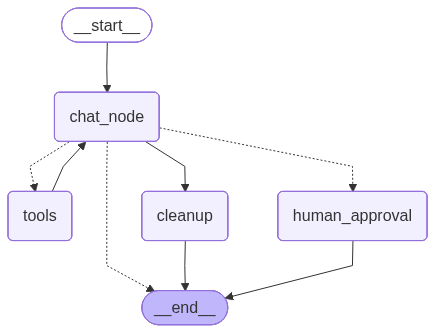

In [29]:
chatbot

In [ ]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India?")]
# }
# chatbot.invoke(initial_state)['messages'][-1].content

In [ ]:
import uuid

# --- Thread selection ---
# The 'checkpoints' table is created by SqliteSaver on the first save.
# On a fresh database it won't exist yet, so we catch that error and
# treat it the same as having no previous threads.
try:
    existing = conn.execute(
        "SELECT DISTINCT thread_id FROM checkpoints ORDER BY thread_id"
    ).fetchall()
except Exception:
    existing = []

if existing:
    print('Existing threads:')
    for i, (tid,) in enumerate(existing, 1):
        print(f'  [{i}] {tid}')
    print(f'  [n] Start a new thread')
    choice = input('Select a thread number or "n" for new: ').strip().lower()
    if choice == 'n' or not choice.isdigit():
        thread_id = str(uuid.uuid4())
        print(f'New thread created: {thread_id}')
    else:
        idx = int(choice) - 1
        thread_id = existing[idx][0]
        print(f'Resuming thread: {thread_id}')
else:
    thread_id = str(uuid.uuid4())
    print(f'No existing threads found. New thread created: {thread_id}')

Existing threads:
  [1] 45081e10-5b54-4bd1-98c9-f142cb6d9677
  [2] d876523a-ba49-45a0-91ec-03ca77842976
  [3] fe49ce79-6f08-4b97-a2a4-5845a4ce3134
  [n] Start a new thread
Resuming thread: fe49ce79-6f08-4b97-a2a4-5845a4ce3134


In [ ]:
# result = 

In [ ]:

# Example:
# User: Plan my day for gym, deep work, meetings
# Step 1:
# plan = generate_day_plan.invoke({"tasks": ["Gym", "Deep Work", "Meetings"]})
# Step 2:
# generate_schedule_pdf.invoke({"plan": plan, "filename": "my_day_plan.pdf"})


In [ ]:
# --- Chat loop ---
while True:

    user_query = input('Ask your query: ')
    print('User: ', user_query)

    if not user_query.strip():
        print('Please enter a non-empty query.')
        continue

    if user_query.strip().lower() in ['exit', 'bye', 'fuck you', 'quit']:
        print('AI: Hope you got answers')
        break

    config = {
        'configurable': {
            'thread_id': thread_id,
            'metadata': {'thread_id': thread_id},
            'run_name': 'chat_turn'
        }
    }

    # input_data starts as the user message; may become Command(resume=...) after an interrupt
    input_data = {'messages': [HumanMessage(content=user_query)]}

    # Loop so we can re-stream after resuming from a human-approval interrupt
    while True:
        interrupted = False

        # stream_mode=["messages", "updates"]:
        #   "messages" → yields (chunk, metadata) tuples for real-time token streaming
        #   "updates"  → yields {node: output} dicts so we can catch __interrupt__ events
        for mode, data in chatbot.stream(
            input_data, config=config, stream_mode=["messages", "updates"]
        ):
            if mode == "messages":
                # Real-time token streaming — skip tool-call-only chunks
                chunk, _ = data
                if hasattr(chunk, 'content') and chunk.content and not getattr(chunk, 'tool_calls', None):
                    print(chunk.content, end='', flush=True)

            elif mode == "updates":
                for node_name, node_output in data.items():
                    if node_name == '__interrupt__':
                        # ---- Human-in-the-Loop: web search approval ----
                        interrupt_info = node_output[0].value
                        print(f"\n\n\ud83d\udd0d [HUMAN APPROVAL REQUIRED]")
                        print(f"   Tool  : {interrupt_info.get('tool_name')}")
                        print(f"   Query : {interrupt_info.get('query')}")
                        approval = input("   Approve web search? (yes/no): ").strip().lower()
                        # Resume the graph with the human's decision
                        input_data = Command(resume={"approved": approval})
                        interrupted = True

        if not interrupted:
            break   # No interrupt this pass — conversation turn is complete

    print()

User:  What is machine learning?
Current token count ->  148
Message Content ->  You haven’t shared your gender with me yet, Kevin! If you’d like, you can let me know, and I’ll remember it for this conversation. 😊
Message Content ->  what is my name?
Message Content ->  Your name is **Kevin**! 😊
Message Content ->  i'm a male
Message Content ->  what is my name ?
Message Content ->  Your name is **Kevin**, and you're a male. How else can I assist you today? 😊
Message Content ->  how am i?
Message Content ->  You're doing great, Kevin! 😊 Is there anything specific on your mind or something I can help with?
Message Content ->  What is machine learning?
**Machine Learning (ML)** is a subset of **Artificial Intelligence (AI)** that focuses on building systems that learn from data, identify patterns, and make decisions with minimal human intervention. Instead of following explicit instructions, machine learning models use **algorithms** and **statistical techniques** to improve their perfor

In [ ]:
# generate_schedule_pdf(plan, "daily_plan.pdf")